# Week 1 ML Assignment


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline 

## Data Loading


In [42]:
df_train = pd.read_csv("train.csv")
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


The Titanic dataset is loaded using pandas. It contains information about passengers such as age, gender, class, fare, and survival status.

The target variable is `Survived`, where:
- 0 = Did not survive
- 1 = Survived


## Exploratory Data Analysis (EDA)


In [43]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [44]:
df_train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [45]:
df_train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


EDA is performed to understand the dataset structure, identify missing values, and analyze feature distributions.

Key observations:
- The dataset contains both numerical and categorical features.
- Missing values are present in Age, Cabin, and Embarked columns.
- Survival is influenced by factors such as passenger class and gender.

## Data Preprocessing


In [46]:
df_train.drop(['Name','Ticket','Cabin'],axis=1,inplace=True)

In [47]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    object 
 4   Age          714 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Fare         891 non-null    float64
 8   Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(2)
memory usage: 62.8+ KB


In [48]:
import warnings

warnings.filterwarnings('ignore')
df_train['Age'].fillna(df_train['Age'].median() , inplace=True)
df_train['Embarked'].fillna(df_train['Embarked'].mode()[0],inplace=True)

In [49]:
df_train.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
dtype: int64

In [50]:
df_train = pd.get_dummies(df_train,drop_first=True)

The following preprocessing steps were applied:

- Removed irrelevant columns (Name, Ticket, Cabin)
- Filled missing values:
  - Age with median
  - Embarked with mode
- Converted categorical variables into numerical format using one-hot encoding

These steps ensure the data is clean and suitable for machine learning models.

## Correlation Heatmap


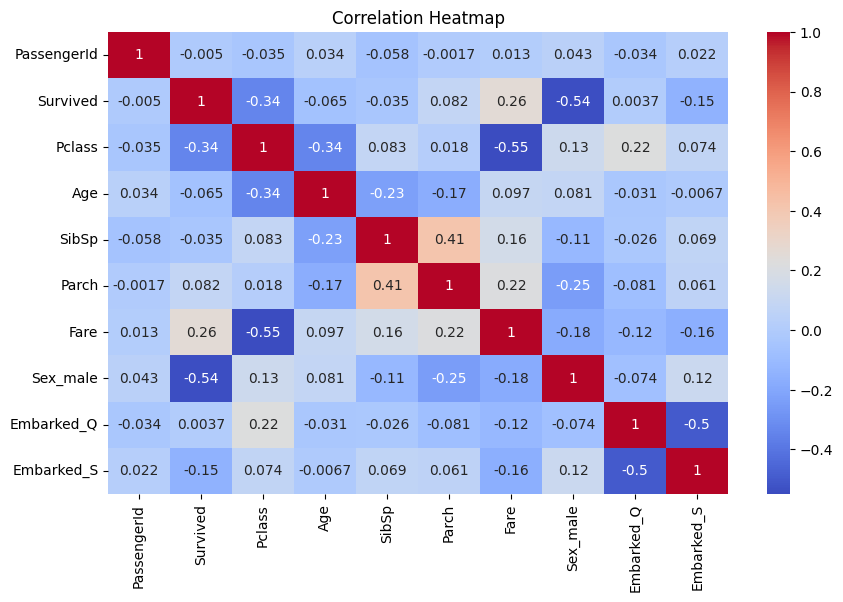

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df_train.corr(), annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

A correlation heatmap is used to visualize relationships between numerical features.

Observations:
- Features like Fare and Pclass show correlation with survival.
- Correlation helps in understanding which features are important for prediction.

## Train-Test Split


In [52]:
from sklearn.model_selection import train_test_split

X= df_train.drop('Survived',axis=1)
y= df_train['Survived']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

The dataset is split into training (80%) and testing (20%) sets.

This helps evaluate the model on unseen data and prevents overfitting.

## Feature Scaling


In [53]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

StandardScaler is used to normalize feature values.

Scaling is important for models like Logistic Regression, which are sensitive to feature magnitude.

## Logistic Regression


In [54]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(X_train,y_train)

y_pred_lr = lr.predict(X_test)

Logistic Regression is a linear model used for binary classification.

It assumes a linear relationship between features and the target variable.

## Random Forest


In [55]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train,y_train)

y_pred_rf = rf.predict(X_test)

Random Forest is an ensemble learning method that uses multiple decision trees.

It captures non-linear relationships and reduces overfitting by averaging multiple trees.

## XGBoost


In [56]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
import warnings

warnings.filterwarnings('ignore')

params = {
    'max_depth':[3,5,7],
    'n_estimators':[100,200],
    'learning_rate':[0.05,0.1]
    
}
grid = GridSearchCV(
    XGBClassifier(use_label_encoder=False,eval_metric='logloss'),
    param_grid=params,
    cv=3,
    scoring='f1',
    verbose=1
)
grid.fit(X_train,y_train)

print("Best")
xgb=grid.best_estimator_
y_pred_xgb = xgb.predict(X_test)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best


XGBoost is a gradient boosting algorithm that builds models sequentially to correct errors from previous models.

Hyperparameter tuning was performed using GridSearchCV to improve model performance.

## Model Evaluation


In [57]:
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix,f1_score

print("LR",accuracy_score(y_test,y_pred_lr))
print("RF",accuracy_score(y_test,y_pred_rf))
print("XGB",accuracy_score(y_test,y_pred_xgb))

LR 0.776536312849162
RF 0.770949720670391
XGB 0.7988826815642458


In [58]:
print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))

Logistic Regression
              precision    recall  f1-score   support

           0       0.77      0.87      0.81       101
           1       0.80      0.65      0.72        78

    accuracy                           0.78       179
   macro avg       0.78      0.76      0.77       179
weighted avg       0.78      0.78      0.77       179

[[88 13]
 [27 51]]


In [59]:
print("Random Forest")
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

Random Forest
              precision    recall  f1-score   support

           0       0.75      0.88      0.81       101
           1       0.80      0.63      0.71        78

    accuracy                           0.77       179
   macro avg       0.78      0.75      0.76       179
weighted avg       0.78      0.77      0.77       179

[[89 12]
 [29 49]]


In [60]:
print("XGBoost")
print(classification_report(y_test, y_pred_xgb))
print(confusion_matrix(y_test, y_pred_xgb))

XGBoost
              precision    recall  f1-score   support

           0       0.76      0.93      0.84       101
           1       0.88      0.63      0.73        78

    accuracy                           0.80       179
   macro avg       0.82      0.78      0.79       179
weighted avg       0.81      0.80      0.79       179

[[94  7]
 [29 49]]


In [61]:
print("Logistic Regression")
print(confusion_matrix(y_test, y_pred_lr))

Logistic Regression
[[88 13]
 [27 51]]


In [62]:
print("Random forest")
print(confusion_matrix(y_test, y_pred_rf))

Random forest
[[89 12]
 [29 49]]


In [63]:
print("XGBoost")
print(confusion_matrix(y_test,y_pred_xgb))

XGBoost
[[94  7]
 [29 49]]


In [64]:
import pandas as pd 

results = pd.DataFrame({
    'Model':['Logistic Regression','RandomForest','XGBoost'],
    'Accuracy':[
        accuracy_score(y_test,y_pred_lr),
        accuracy_score(y_test,y_pred_rf),
        accuracy_score(y_test,y_pred_xgb)
    ],
    'F1 Score':[
    f1_score(y_test,y_pred_lr),
    f1_score(y_test,y_pred_rf),
    f1_score(y_test,y_pred_xgb)]
})
results

,Model,Accuracy,F1 Score
0,Logistic Regression,0.776536,0.718310
1,RandomForest,0.770950,0.705036
2,XGBoost,0.798883,0.731343


All models are compared based on Accuracy and F1 Score.

This helps in selecting the best model for the problem.

The models are evaluated using the following metrics:

- Accuracy: Measures overall correctness
- F1 Score: Balances precision and recall
- Confusion Matrix: Shows detailed prediction performance

These metrics provide a comprehensive understanding of model performance.

## Feature Importance


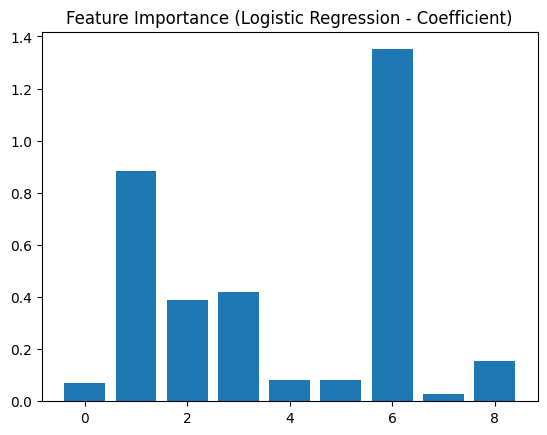

In [67]:
import matplotlib.pyplot as plt 
import numpy as np 

importance_lr = np.abs(lr.coef_[0])

plt.bar(range(len(importance_lr)),importance_lr)
plt.title("Feature Importance (Logistic Regression - Coefficient)")
plt.show()

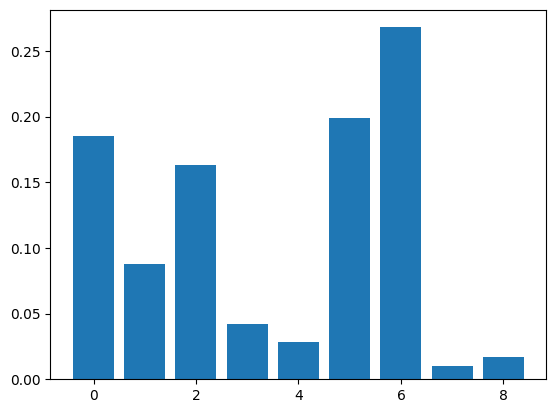

In [68]:
import matplotlib.pyplot as plt 

plt.bar(range(len(rf.feature_importances_)),rf.feature_importances_)
plt.show()

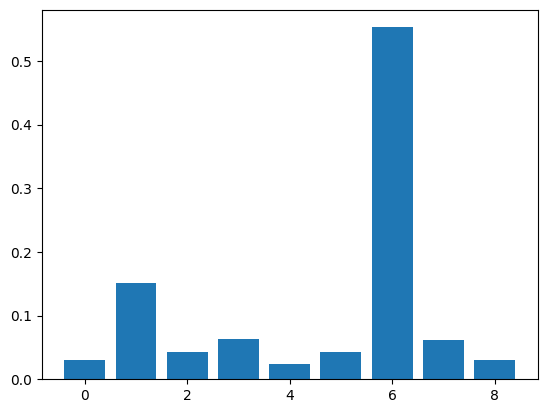

In [69]:
import matplotlib.pyplot as plt 

plt.bar(range(len(xgb.feature_importances_)),xgb.feature_importances_)
plt.show()

Feature importance helps identify which features contribute most to predictions.

- Tree-based models (Random Forest, XGBoost) provide feature importance directly
- Logistic Regression uses coefficients to indicate feature influence

## Conclusion

The models were trained and evaluated using Accuracy and F1 Score.

- Logistic Regression achieved moderate performance with decent accuracy and F1 score.
- Random Forest performed slightly lower, possibly due to lack of hyperparameter tuning.
- XGBoost achieved the best performance with the highest accuracy and F1 score.

This indicates that XGBoost is more effective in capturing complex patterns in the dataset.

Overall, XGBoost is selected as the best model for this problem.